# Student Survey Analysis

## What This Notebook Is About

This notebook analyses responses from a student survey, comparing **11 variables** across gender groups. The goal is to identify which differences are statistically meaningful versus which might just be random noise.

---

### The Central Question

For each measured variable (e.g. haircut spend, exercise hours, anxiety about analytics), we ask:
> **"Is the difference between male and female students large enough that it's unlikely to be due to chance?"**

This is the classic two-sample hypothesis testing problem.

---

### Why "Statistical Significance" Alone Isn't Enough

A critical lesson in this notebook: with 283 students, **even tiny differences can produce a significant p-value**. Always check:

1. **p-value**: Is the difference statistically significant? (p < 0.05 = yes)
2. **Effect size**: How large is the actual difference? (look at the means and the CI)
3. **Practical significance**: Does the difference *matter* in the real world?

A 2-minute difference in daily exercise might be statistically significant but practically irrelevant.

---

### What You Will Learn

| Concept | Where |
|---|---|
| `favstats_by_group()`: custom summary stats with 95% CI | Section 3 |
| `t.ppf(0.975, df=n-1)`: the t critical value | Section 3 |
| `lambda n: ...` inside `.apply()`: row-wise computation | Section 3 |
| Looping over multiple variables to build plots | Section 5 |
| `nan_policy='omit'` in t-tests: handling missing data | Section 6 |
| Interpreting significance stars (`*`, `**`, `***`) | Section 6 |

---

### Libraries Used
- **`scipy.stats`** — `ttest_ind`, `t.ppf`
- **`pandas`** — `groupby`, `agg`, `describe`
- **`seaborn`** — `boxplot`
- **`matplotlib`** — subplot layout, histogram overlay

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import t
import warnings

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['font.size']   = 12
plt.rcParams['font.family'] = 'sans-serif'

## 2. Load Data

In [5]:
survey = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/student_survey.csv")
survey.head()


,height,siblings,exercise_hrs,online_hrs,sleep_hrs,haircut_spend,type_of_person,homeopathy_works,lied_about_age,marijuana,handedness,success_forces_outside_control,work_hard_to_succeed,children_vs_parents,woman_top_position,relaxed_stressful,anxiety_about_analytics,motivated_course_grade,facebook_friends,gender
0,192.0,1,8.0,40,8.0,23.0,4,0,0,NaN,0.6,Disagree,6.0,Worse off,NaN,2.0,4.0,4.0,1,Male
1,185.0,3,1.0,20,7.0,20.0,1,0,0,NaN,1.0,Disagree,7.0,Better off,Not having children at all,2.0,5.0,2.0,200,Male
2,175.0,2,2.0,35,7.0,20.0,2,1,0,NaN,1.0,Disagree,10.0,Better off,Having children later in her career,4.0,4.0,5.0,509,Male
3,175.0,2,4.0,8,7.0,50.0,3,1,0,NaN,-1.0,Agree,6.0,Better off,NaN,4.0,4.0,4.0,89,Male
4,164.6,2,1.0,30,6.5,25.0,1,1,0,NaN,1.0,Disagree,8.0,Better off,Having children later in her career,2.0,5.0,4.0,421,Female


## 3. Helper Function: `favstats_by_group`

For each group it computes: min, max, mean, median, SD, n, standard error, and the **95% confidence interval** around the mean using the t-distribution.

The formula is: `mean +/- t_critical * (sd / sqrt(n))`

In [6]:
def favstats_by_group(df, value, group):
    """
    Grouped summary statistics with 95% confidence interval for the mean.

    Equivalent to mosaic::favstats() in R, but extended with CI columns.

    Parameters
    ----------
    df    : pd.DataFrame  — the dataset
    value : str           — numeric column to summarise (e.g. 'haircut_spend')
    group : str           — categorical column to group by (e.g. 'gender')

    Returns
    -------
    pd.DataFrame with one row per group, including min, max, mean, median,
    std, count, se (standard error), lower_ci, upper_ci
    """
    # Step 1: groupby + agg computes multiple statistics at once
    # Each string in the list becomes a column name in the result
    summary = df.groupby(group)[value].agg(['min', 'max', 'mean', 'median', 'std', 'count'])

    # Step 2: Standard Error (SE) = how precisely we've estimated the group mean
    # SE = std / sqrt(n)
    # Smaller SE → more data → more precise estimate of the mean
    summary['se'] = summary['std'] / np.sqrt(summary['count'])

    # Step 3: t critical value for a 95% CI
    # t.ppf(0.975, df=n-1) = the value that cuts off 2.5% in each tail of the t-distribution
    # For large n, this approaches 1.96 (the familiar normal distribution value)
    # For small n, it's larger — reflecting more uncertainty with less data
    #
    # .apply(lambda n: ...) applies the function to EACH value in the 'count' column
    # if n > 1: only compute if we have more than 1 observation (can't compute df=0)
    summary['t_crit'] = summary['count'].apply(
        lambda n: t.ppf(0.975, df=n - 1) if n > 1 else np.nan
    )

    # Step 4: CI bounds = mean ± t_critical × SE
    # This gives the range that would contain the TRUE population mean 95% of the time
    # if we repeated this survey many times
    summary['lower_ci'] = summary['mean'] - summary['t_crit'] * summary['se']
    summary['upper_ci'] = summary['mean'] + summary['t_crit'] * summary['se']

    # Drop the intermediate t_crit column from the final display
    summary = summary.drop(columns=['t_crit'])

    return summary.round(2)

print("Helper function defined.")

Helper function defined.


## 4. Define Variables to Analyse

Each tuple is `(column_name, readable_label)`.

In [7]:
variables = [
    ('haircut_spend',           'Haircut Spend'),
    ('exercise_hrs',            'Exercise Hours'),
    ('online_hrs',              'Online Hours'),
    ('sleep_hrs',               'Sleep Hours'),
    ('facebook_friends',        'Facebook Friends'),
    ('motivated_course_grade',  'Motivation'),
    ('relaxed_stressful',       'Stress During the Day'),
    ('anxiety_about_analytics', 'Anxiety About Analytics'),
    ('homeopathy_works',        'Homeopathy'),
    ('lied_about_age',          'Lied About Age'),
    ('marijuana',               'Marijuana'),
]

print(f"{len(variables)} variables to analyse.")

11 variables to analyse.


## 5. Distribution Plots by Gender

For each numeric variable we produce two side-by-side panels:
- **Left — Boxplot**: shows median, IQR, and outliers per gender
- **Right — Density histogram**: overlapping distributions per gender, normalised to density so groups with different sizes are comparable

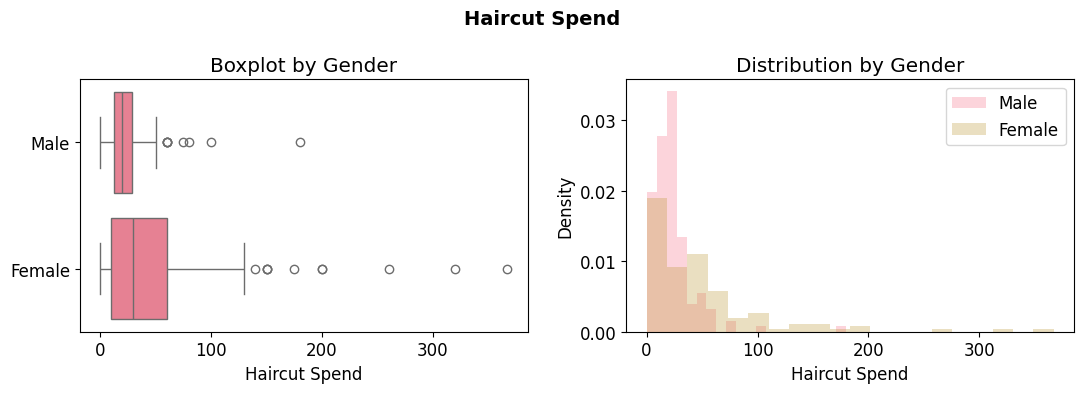

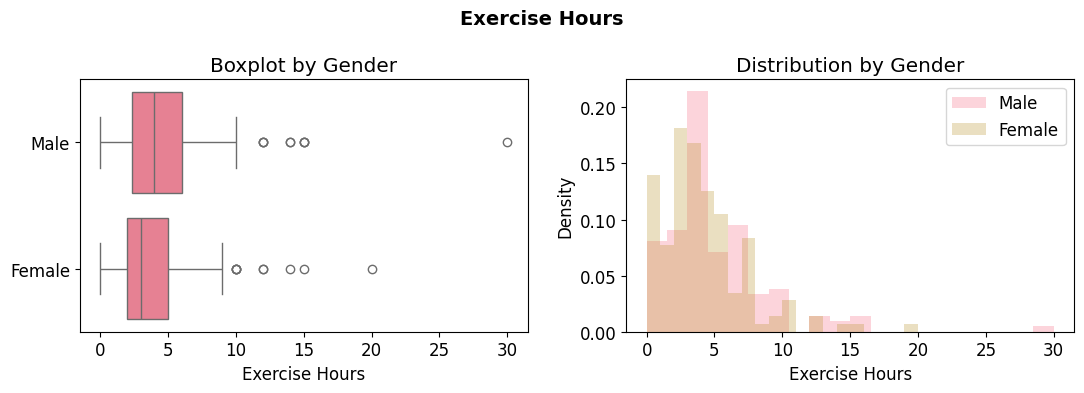

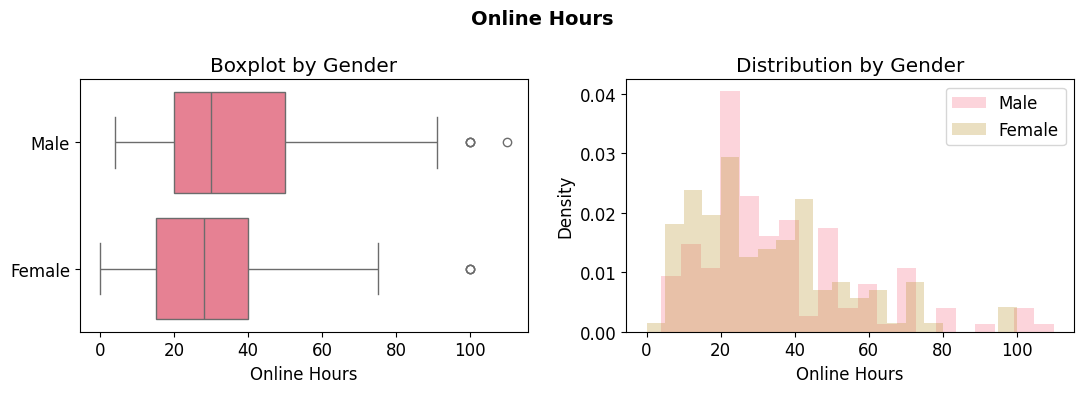

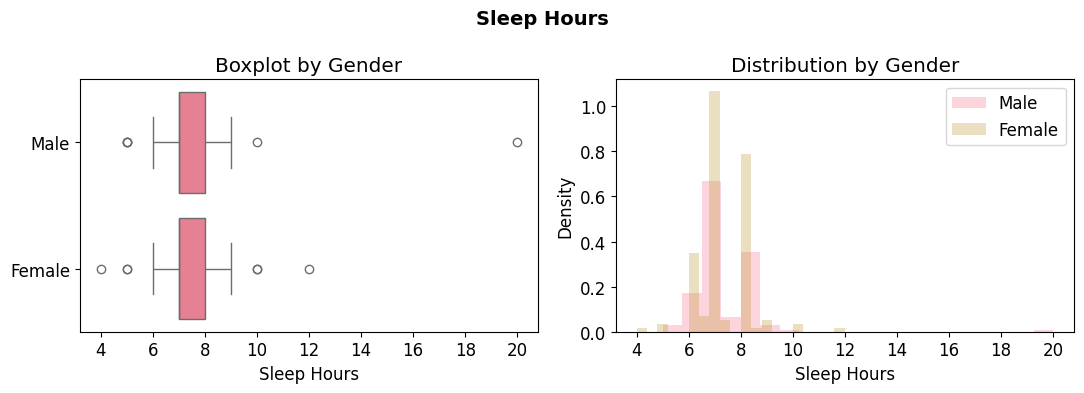

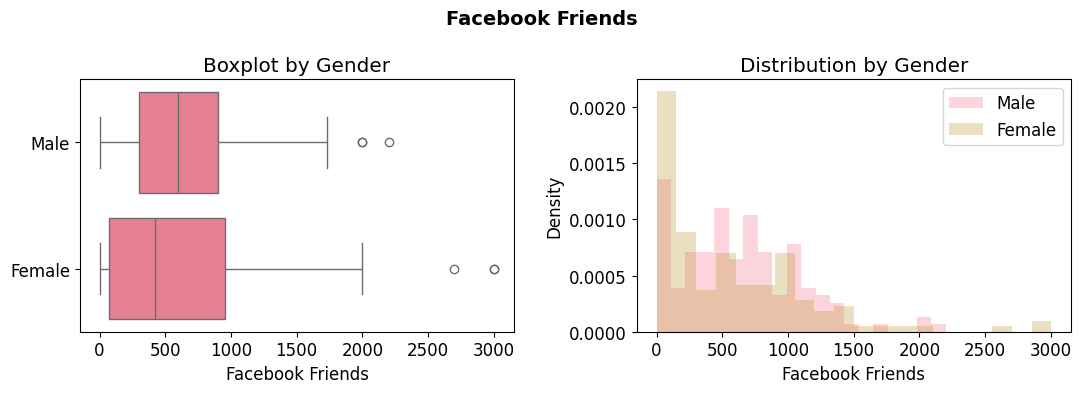

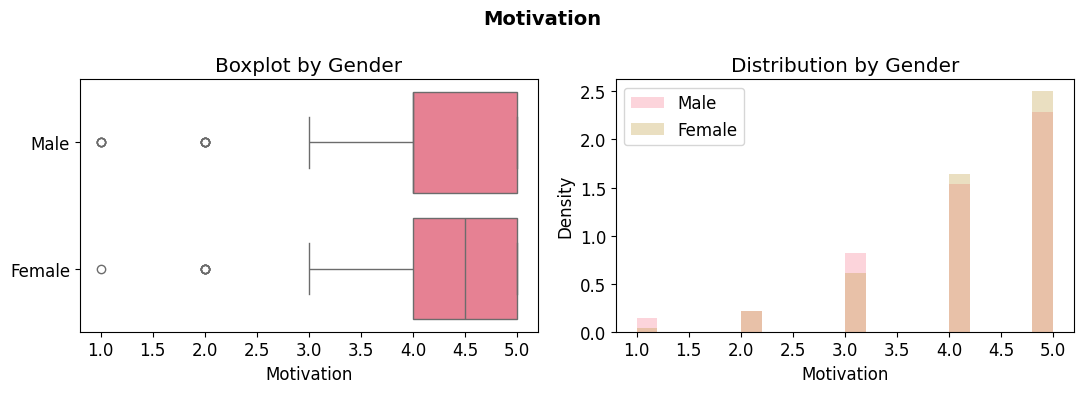

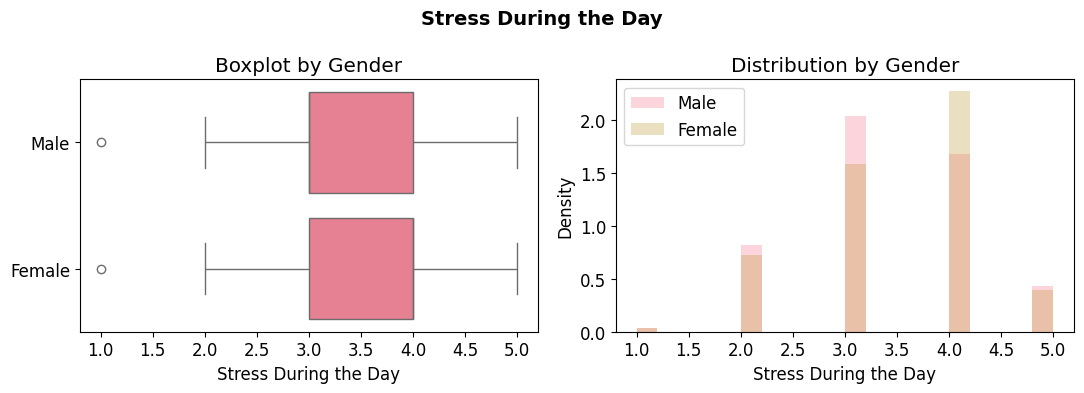

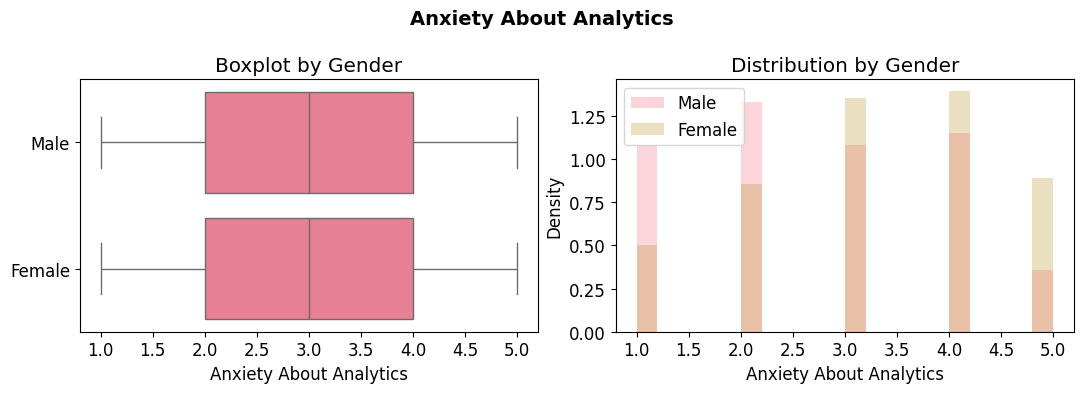

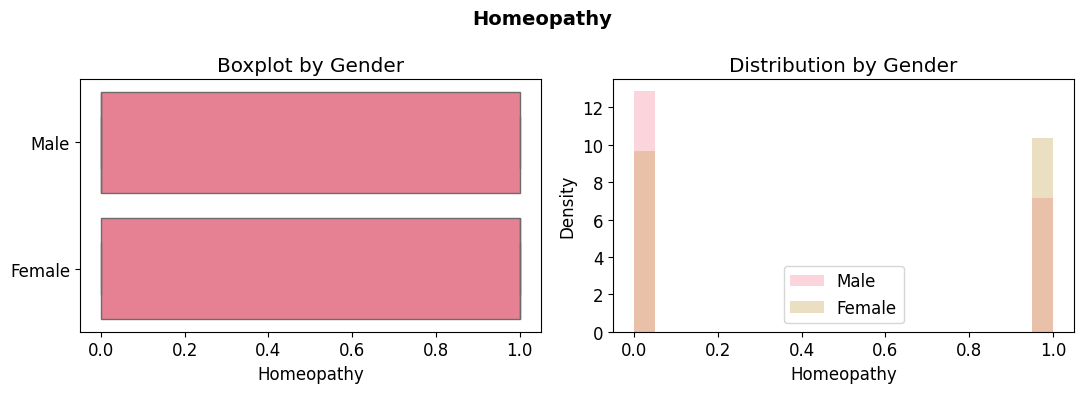

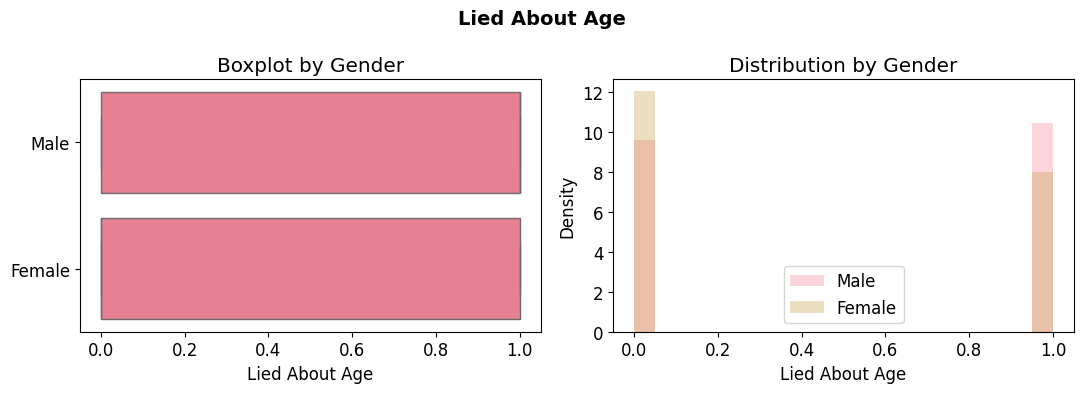

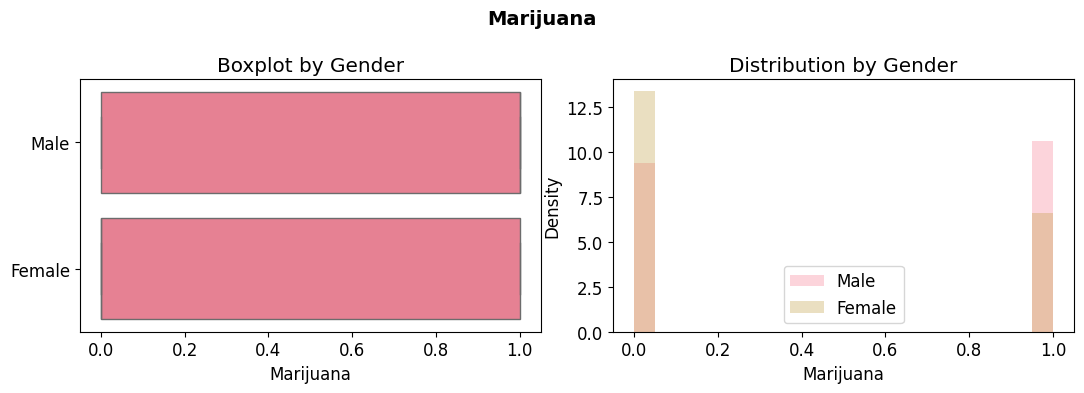

In [8]:
# =============================================================================
# SECTION 5: Distribution Plots by Gender
# =============================================================================
# We loop over ALL 11 variables and produce the same two-panel chart for each.
# This is the "loop + visualise" pattern — more efficient than copy-pasting
# the same plotting code 11 times.
#
# THE LOOP STRUCTURE:
#   for var, label in variables:
#       var   = the column name in the DataFrame (e.g. 'haircut_spend')
#       label = the human-readable name for titles (e.g. 'Haircut Spend')
#
# SKIPPING NON-NUMERIC COLUMNS:
#   Some survey responses are text (e.g. 'woman_top_position' is a free-text answer).
#   We can't make a histogram or run a t-test on text.
#   if survey[var].dtype not in [np.float64, np.int64]: continue
#   → 'continue' skips the rest of this loop iteration and jumps to the next variable
#
# SIDE-BY-SIDE SUBPLOTS:
#   plt.subplots(1, 2) creates 1 row × 2 columns of axes.
#   (ax1, ax2) unpacks the two axes: ax1=left panel, ax2=right panel.
#   Both panels share the SAME figure object (fig).
#   fig.suptitle() places a title ABOVE both panels.

for var, label in variables:
    # Skip non-numeric columns (e.g. text survey responses)
    if survey[var].dtype not in [np.float64, np.int64]:
        continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(label, fontsize=14, fontweight='bold')

    # --- Left panel: Boxplot ---
    # Horizontal boxplot (x=var) to make long axis labels readable
    # y='gender': one boxplot row per gender
    sns.boxplot(data=survey, x=var, y='gender', ax=ax1)
    ax1.set_title('Boxplot by Gender')
    ax1.set_xlabel(label)
    ax1.set_ylabel('')

    # --- Right panel: Overlapping density histograms ---
    # We loop over gender categories and add each histogram to the SAME axes (ax2)
    # density=True: normalises the y-axis to probability density (not raw counts)
    #   → makes groups with different sample sizes directly comparable
    # alpha=0.3: semi-transparent fill; when histograms overlap, both are visible
    # bins=20: number of histogram bars (more bins = finer resolution, more noise)
    for gender in survey['gender'].unique():
        subset = survey[survey['gender'] == gender][var].dropna()
        ax2.hist(subset, alpha=0.3, density=True, label=gender, bins=20)
    ax2.set_xlabel(label)
    ax2.set_ylabel('Density')
    ax2.set_title('Distribution by Gender')
    ax2.legend()

    plt.tight_layout()   # auto-adjust spacing between subplots
    plt.show()

## 6. Summary Statistics & T-Tests

For each variable we:
1. Print the `favstats_by_group` table (mean, CI, n, etc.)
2. Run a **Welch independent samples t-test** (`equal_var=False`)
   - `nan_policy='omit'` safely ignores missing values
   - p <= 0.05 is the conventional threshold for statistical significance

> **Reminder**: with a large enough sample, almost any difference becomes statistically significant. Always check the *size* of the difference (practical significance), not just the p-value.

In [9]:
# =============================================================================
# SECTION 6: Summary Statistics + T-Tests for all 11 variables
# =============================================================================
# Same loop pattern as Section 5, but now we:
#   1. Display the favstats_by_group table (mean, CI, n, etc.)
#   2. Run a Welch two-sample t-test between the two genders
#
# KEY CONCEPT: nan_policy='omit'
# ================================
# Some survey questions were not answered by everyone.
# stats.ttest_ind() by default raises an error if it encounters NaN values.
# nan_policy='omit': silently ignore rows with NaN values — only use valid responses.
# This is the safest approach when missing data is scattered across columns.
#
# HOW TO READ THE T-TEST OUTPUT:
#   t = 2.509, p = 0.013 *
#   - t-statistic: how many standard errors the observed difference is from zero
#     Large |t| means the groups are far apart relative to within-group variation
#   - p-value: probability of seeing a difference this large (or larger) if H₀ were true
#     p < 0.05 → reject H₀ (the difference is unlikely due to chance)
#   - Stars: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant
#
# IMPORTANT CAVEAT (see section intro):
#   With n=283, even a 1-point difference on a 5-point scale can be "significant".
#   Always look at the ACTUAL MEANS and the CI — not just the p-value.

genders = survey['gender'].unique()   # e.g. ['Male', 'Female']

for var, label in variables:
    print(f"\n{'='*55}")
    print(f"  {label}  ({var})")
    print('='*55)

    # --- Summary statistics with 95% CI ---
    # display() renders the DataFrame as a formatted table in Jupyter
    display(favstats_by_group(survey, var, 'gender'))

    # --- Welch two-sample t-test ---
    # Split the full dataset into two Series, one per gender
    group1 = survey[survey['gender'] == genders[0]][var]
    group2 = survey[survey['gender'] == genders[1]][var]

    # equal_var=False → Welch's t-test (no equal-variance assumption)
    # nan_policy='omit' → skip rows with missing values instead of crashing
    t_stat, p_value = stats.ttest_ind(group1, group2, nan_policy='omit')

    # Significance stars: a quick summary of evidence strength
    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    print(f"\nWelch t-test: t = {t_stat:.3f},  p = {p_value:.3f}  {sig}")
    if p_value <= 0.05:
        print(f"  -> Statistically significant difference between genders (p <= 0.05)")
    else:
        print(f"  -> No statistically significant difference detected (p > 0.05)")


  Haircut Spend  (haircut_spend)


,min,max,mean,median,std,count,se,lower_ci,upper_ci
gender,,,,,,,,,
Female,0.0,367.0,48.36,30.0,57.26,143,4.79,38.9,57.83
Male,0.0,180.0,23.33,20.0,21.15,140,1.79,19.8,26.87



Welch t-test: t = -4.858,  p = 0.000  ***
  -> Statistically significant difference between genders (p <= 0.05)

  Exercise Hours  (exercise_hrs)


,min,max,mean,median,std,count,se,lower_ci,upper_ci
gender,,,,,,,,,
Female,0.0,20.0,3.76,3.0,3.25,143,0.27,3.22,4.29
Male,0.0,30.0,4.84,4.0,3.99,140,0.34,4.17,5.51



Welch t-test: t = 2.509,  p = 0.013  *
  -> Statistically significant difference between genders (p <= 0.05)

  Online Hours  (online_hrs)


...


Welch t-test: t = -2.744,  p = 0.006  **
  -> Statistically significant difference between genders (p <= 0.05)

  Lied About Age  (lied_about_age)


,min,max,mean,median,std,count,se,lower_ci,upper_ci
gender,,,,,,,,,
Female,0,1,0.40,0.0,0.49,143,0.04,0.32,0.48
Male,0,1,0.52,1.0,0.50,140,0.04,0.44,0.61



Welch t-test: t = 2.082,  p = 0.038  *
  -> Statistically significant difference between genders (p <= 0.05)

  Marijuana  (marijuana)


,min,max,mean,median,std,count,se,lower_ci,upper_ci
gender,,,,,,,,,
Female,0.0,1.0,0.33,0.0,0.47,139,0.04,0.25,0.41
Male,0.0,1.0,0.53,1.0,0.50,134,0.04,0.44,0.62



Welch t-test: t = 3.377,  p = 0.001  ***
  -> Statistically significant difference between genders (p <= 0.05)
